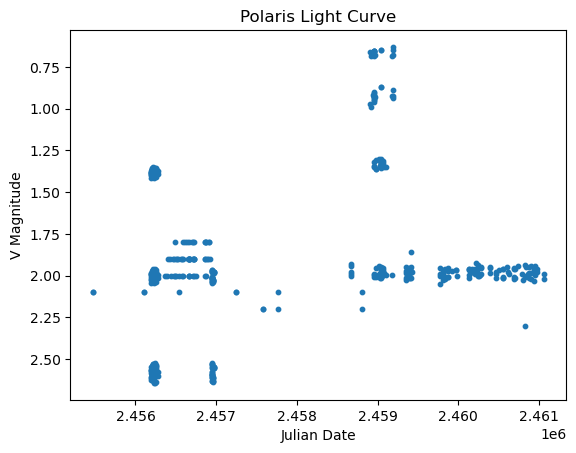

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

data = np.loadtxt("polaris.txt", delimiter=',', skiprows=1, usecols=(0,1))

time = data[:,0]
mag = data[:,1]  

plt.figure()
plt.scatter(time, mag, s=10)
plt.gca().invert_yaxis()   
plt.xlabel("Julian Date")
plt.ylabel("V Magnitude")
plt.title("Polaris Light Curve")
plt.show()

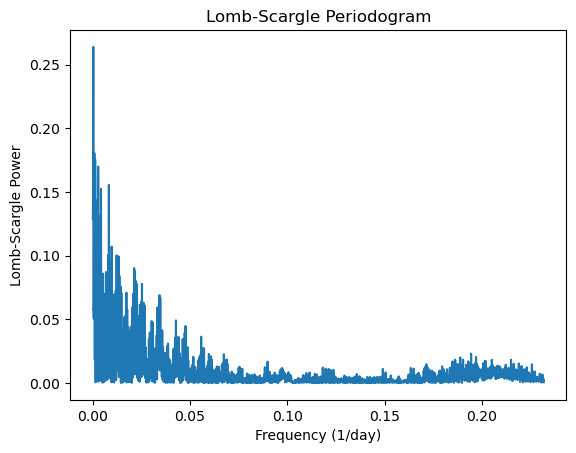

In [15]:
frequency, power = LombScargle(time, mag).autopower()

plt.figure()
plt.plot(frequency, power)
plt.xlabel("Frequency (1/day)")
plt.ylabel("Lomb-Scargle Power")
plt.title("Lomb-Scargle Periodogram")
plt.show()

In [16]:
best_frequency = frequency[np.argmax(power)]
best_period = 1 / best_frequency

print("Best period:", best_period)

Best period: 3723.51733333338


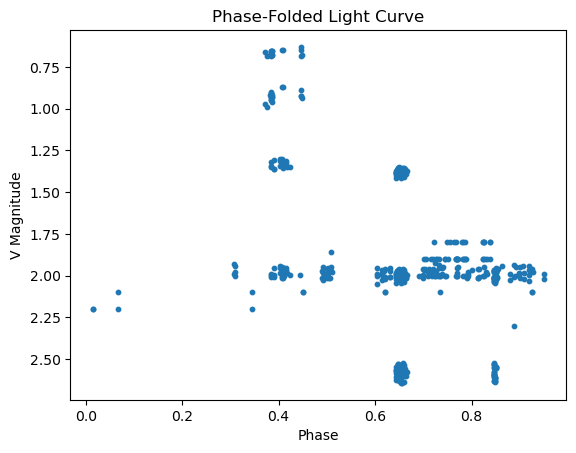

In [17]:
phase = (time % best_period) / best_period

plt.figure()
plt.scatter(phase, mag, s=10)
plt.gca().invert_yaxis()
plt.xlabel("Phase")
plt.ylabel("V Magnitude")
plt.title("Phase-Folded Light Curve")
plt.show()